In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

# Cargar los datos
pca_path = "../data/processed/healthcare_pca.csv"
orig_path = "../data/interim/healtcare_processedv2.csv"

df_pca = pd.read_csv(pca_path)
df_orig = pd.read_csv(orig_path)

print("PCA dataset shape:", df_pca.shape)
print("Original dataset shape:", df_orig.shape)

PCA dataset shape: (1196, 14)
Original dataset shape: (54966, 13)


In [2]:
# Definir el rango de clusters para el parameter sweep
ks = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, labels))

results = pd.DataFrame({
    "k": list(ks),
    "inertia": inertia_scores,
    "silhouette": silhouette_scores
})

results

,k,inertia,silhouette
0,2,14316.451596,0.578815
1,3,13183.050244,0.577231
2,4,12111.747619,0.109820
3,5,11215.783845,0.116989
4,6,10733.325551,0.095174
5,7,10460.661030,0.084038
6,8,10206.850052,0.082290
7,9,9929.052346,0.076372
8,10,9711.853049,0.077025


In [3]:
# Si K_CHOICE = None, se usará automáticamente el mejor K según silhouette score
# Si K_CHOICE = un número (2-10), se usará ese valor de K
K_CHOICE = 3  # Cambiar a un número entero entre 2 y 10 si lo deseas

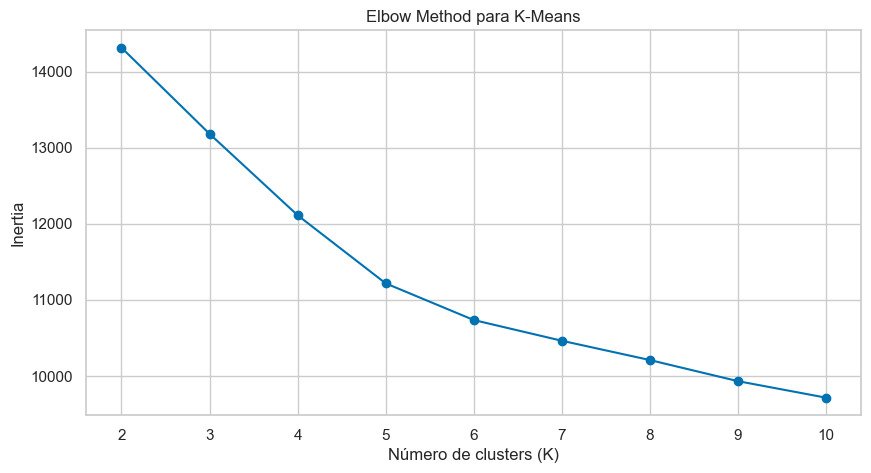

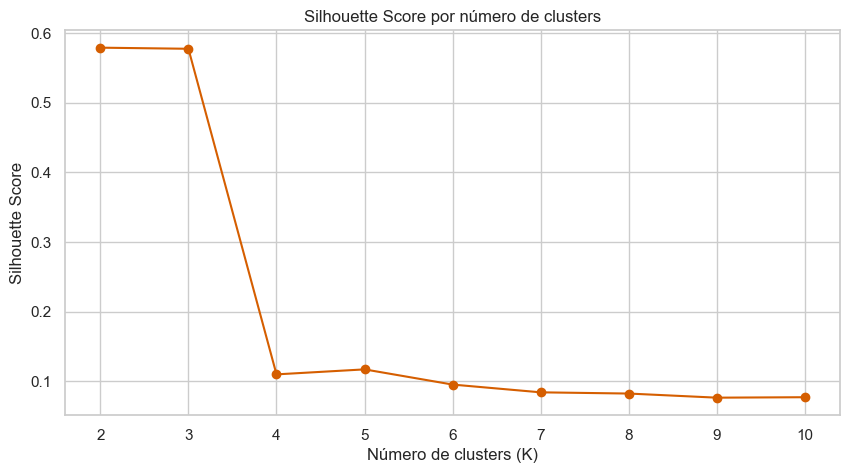

In [5]:
# Visualizar Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(results["k"], results["inertia"], marker="o", linestyle="-", color="#0072B2")
plt.title("Elbow Method para K-Means")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.xticks(results["k"])
plt.grid(True)
plt.show()

# Visualizar silhouette score
plt.figure(figsize=(10, 5))
plt.plot(results["k"], results["silhouette"], marker="o", linestyle="-", color="#D55E00")
plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(results["k"])
plt.grid(True)
plt.show()

In [6]:
# Elegir K: usar el valor configurado o el mejor según silhouette
if K_CHOICE is not None:
    best_k = K_CHOICE
    best_index = int(np.where(results["k"] == K_CHOICE)[0][0])
    print(f"Usando K configurado manualmente: {best_k}")
else:
    best_index = int(np.argmax(results["silhouette"]))
    best_k = results.loc[best_index, "k"]
    print(f"Mejor valor de K según silhouette score: {best_k}")

print(f"Silhouette score para K={best_k}: {results.loc[best_index, 'silhouette']:.4f}")
print(f"Inertia para K={best_k}: {results.loc[best_index, 'inertia']:.4f}")

# Ajustar el modelo final con el K elegido y agregar etiquetas al dataset original
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(df_pca)

df_orig = df_orig.copy()
# Assign cluster labels only to rows corresponding to df_pca to avoid length mismatch
df_orig["cluster"] = pd.NA
df_orig.loc[df_pca.index, "cluster"] = pd.Series(cluster_labels, index=df_pca.index)
df_orig["cluster"] = df_orig["cluster"].astype("Int64")

cluster_counts = df_orig["cluster"].value_counts().sort_index()
print("\nTamaño de cada cluster:")
print(cluster_counts)

Usando K configurado manualmente: 3
Silhouette score para K=3: 0.5772
Inertia para K=3: 13183.0502

Tamaño de cada cluster:
cluster
0    1087
1      62
2      47
Name: count, dtype: Int64


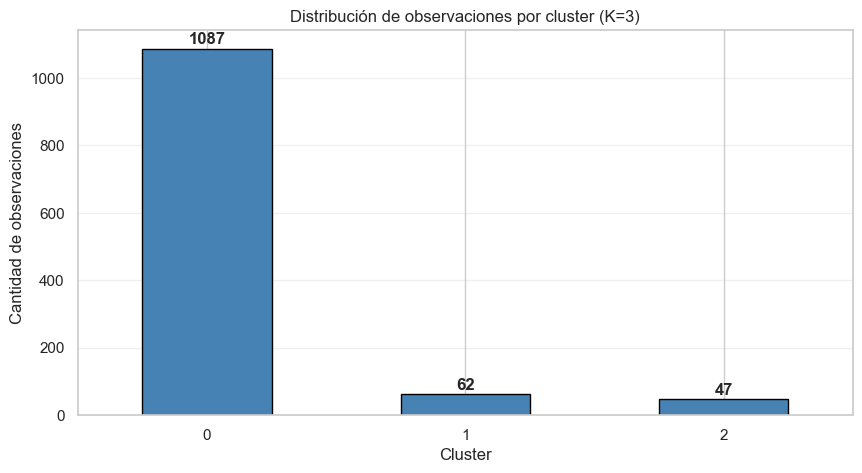

In [7]:
# Gráfico de distribución de tamaños de clusters
plt.figure(figsize=(10, 5))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f"Distribución de observaciones por cluster (K={best_k})")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de observaciones")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.show()

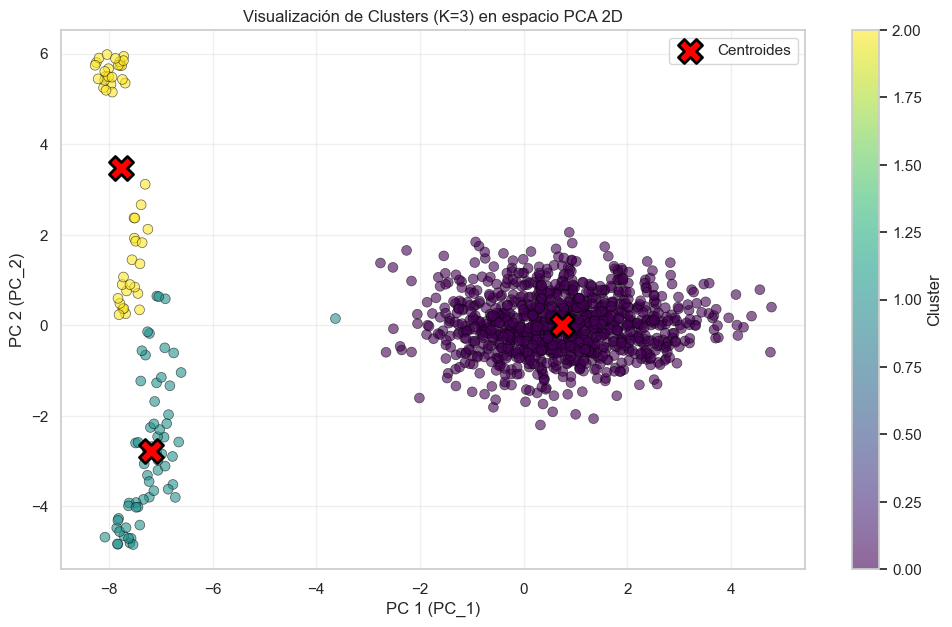

In [8]:
# Scatter plot de clusters en los dos primeros componentes PCA
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_pca.iloc[:, 0],
    df_pca.iloc[:, 1],
    c=cluster_labels,
    cmap='viridis',
    s=50,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5
)
plt.scatter(
    final_kmeans.cluster_centers_[:, 0],
    final_kmeans.cluster_centers_[:, 1],
    marker='X',
    s=300,
    c='red',
    edgecolor='black',
    linewidth=2,
    label='Centroides'
)
plt.xlabel(f"PC 1 ({df_pca.columns[0]})")
plt.ylabel(f"PC 2 ({df_pca.columns[1]})")
plt.title(f"Visualización de Clusters (K={best_k}) en espacio PCA 2D")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Visualización de Clusters

A continuación se visualizan los clusters en el espacio PCA reducido para entender la distribución espacial de los grupos encontrados.

### Interpretación de clusters

A continuación se muestran las características agrupadas por cluster para investigar cómo se distribuyen las variables originales en cada grupo.

In [9]:
cluster_summary = df_orig.groupby("cluster").agg({
    "Age": ["mean", "median"],
    "Gender": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    "Blood Type": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    "Medical Condition": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    "Medication": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    "Admission Type": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
})

cluster_summary.columns = ["_" . join(col).strip() for col in cluster_summary.columns.values]
cluster_summary

,Age_mean,Age_median,Gender_<lambda>,Blood Type_<lambda>,Medical Condition_<lambda>,Medication_<lambda>,Admission Type_<lambda>
cluster,,,,,,,
0,50.983441,51.0,1,6,0,1,0
1,47.774194,43.5,0,3,0,3,2
2,52.553191,49.0,0,4,1,3,0


In [10]:
import os

# Guardar resultados de cluster en un CSV si es necesario
output_path = "../data/processed/healthcare_pca_clusters.csv"

# Crear el directorio si no existe
output_dir = os.path.dirname(output_path)
os.makedirs(output_dir, exist_ok=True)

df_orig.to_csv(output_path, index=False)
print(f"Resultados de clustering guardados en: {output_path}")

Resultados de clustering guardados en: ../data/processed/healthcare_pca_clusters.csv


In [11]:
import joblib

# Guardar el modelo K-Means entrenado
model_path = "../data/processed/kmeans_model_final.pkl"
joblib.dump(final_kmeans, model_path)
print(f"Modelo K-Means entrenado guardado en: {model_path}")

# Información del modelo entrenado
print(f"\n=== Información del Modelo K-Means Entrenado ===")
print(f"Número de clusters: {final_kmeans.n_clusters}")
print(f"Inercia: {final_kmeans.inertia_:.4f}")
print(f"Número de iteraciones: {final_kmeans.n_iter_}")
print(f"Forma de centroides: {final_kmeans.cluster_centers_.shape}")
print(f"Total de observaciones entrenadas: {len(cluster_labels)}")

Modelo K-Means entrenado guardado en: ../data/processed/kmeans_model_final.pkl

=== Información del Modelo K-Means Entrenado ===
Número de clusters: 3
Inercia: 13183.0502
Número de iteraciones: 10
Forma de centroides: (3, 14)
Total de observaciones entrenadas: 1196


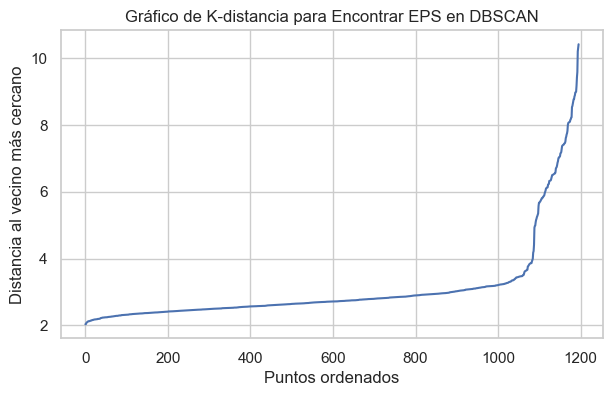

=== Barrido de Parámetros para DBSCAN ===
EPS: 0.5 | MinSamples: 5 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 0.5 | MinSamples: 10 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 0.5 | MinSamples: 20 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 1.0 | MinSamples: 5 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 1.0 | MinSamples: 10 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 1.0 | MinSamples: 20 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 1.5 | MinSamples: 5 -> Clusters: 1 | Ruido: 1190 | Silueta: No calculable (no hay suficientes clusters o puntos > 1).
EPS: 1.5 | MinSamples: 10 -> Clusters: 0 | Ruido: 1196 | Silueta: No calculable (no hay sufic

In [12]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 1. Encontrar el EPS óptimo usando el método de la rodilla (K-distance graph)
# Usamos n_neighbors = 2 * dimensiones del dataset (por ejemplo, si tras PCA tienes 3 componentes)
n_features = df_pca.shape[1]
neighbors = NearestNeighbors(n_neighbors=2 * n_features)
neighbors_fit = neighbors.fit(df_pca)
distances, indices = neighbors_fit.kneighbors(df_pca)

# Ordenar distancias y graficar
distances = np.sort(distances[:, -1], axis=0)
plt.figure(figsize=(7, 4))
plt.plot(distances)
plt.title("Gráfico de K-distancia para Encontrar EPS en DBSCAN")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al vecino más cercano")
plt.grid(True)
plt.show()

print("=== Barrido de Parámetros para DBSCAN ===")
# Aumentamos el rango de eps, ya que los valores anteriores no encontraron clusters.
for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]: # Rango de eps ajustado
    for min_samples in [5, 10, 20]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df_pca)


        core_samples_mask = (labels != -1)

        distinct_cluster_labels = set(labels[core_samples_mask])


        if len(distinct_cluster_labels) > 1 and np.sum(core_samples_mask) > 1:
            score = silhouette_score(df_pca[core_samples_mask], labels[core_samples_mask])
            n_clusters = len(distinct_cluster_labels)
            noise_count = np.sum(labels == -1)
            print(f"EPS: {eps:.1f} | MinSamples: {min_samples} -> Clusters: {n_clusters} | Ruido: {noise_count} | Silueta (sin ruido): {score:.4f}")
        else:
            # De no ser valido el cluster o haber problemas se procede a imprimir un mensaje de falta de claves
            n_clusters = len(distinct_cluster_labels)
            noise_count = np.sum(labels == -1)
            print(f"EPS: {eps:.1f} | MinSamples: {min_samples} -> Clusters: {n_clusters} | Ruido: {noise_count} | Silueta: No calculable (no hay suficientes clusters o puntos > 1).")

In [14]:
from sklearn.metrics import calinski_harabasz_score, silhouette_samples

#import pandas as pd
#import numpy as np
#from sklearn.cluster import DBSCAN
#from sklearn.metrics import silhouette_score, calinski_harabasz_score, silhouette_samples
#import matplotlib.pyplot as plt
#import seaborn as sns


best_eps = 2.5
best_min_samples = 5

dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)

dbscan_labels = dbscan_best.fit_predict(df_pca)



sil_km = silhouette_score(df_pca, final_kmeans.labels_)
ch_km = calinski_harabasz_score(df_pca, final_kmeans.labels_)
n_clusters_km = final_kmeans.n_clusters

# Métricas para DBSCAN
db_mask = dbscan_labels != -1
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if n_clusters_db > 0 and np.sum(db_mask) > 1:
    sil_db = silhouette_score(df_pca[db_mask], dbscan_labels[db_mask])
    ch_db = calinski_harabasz_score(df_pca[db_mask], dbscan_labels[db_mask])
else:
    sil_db, ch_db = np.nan, np.nan

ruido_db = np.sum(dbscan_labels == -1)

tabla_validacion = pd.DataFrame({
    "Métrica / Criterio": [
        "Número de Clústeres detectados",
        "Coeficiente de Silueta",
        "Índice Calinski-Harabasz",
        "Puntos de Ruido (Outliers / No Agrupados)"
    ],
    "K-Means (K=3)": [n_clusters_km, f"{sil_km:.4f}", f"{ch_km:.2f}", "0 (Fuerza a agrupar todo)"],
    "DBSCAN (Eps=2.5, Min=5)": [n_clusters_db, f"{sil_db:.4f}", f"{ch_db:.2f}", f"{ruido_db} ({ruido_db/len(df_pca)*100:.1f}%)" ]})

print("\n" + "="*50)
print("             TABLA DE VALIDACIÓN FINAL")
print("="*50)
print(tabla_validacion.to_string(index=False))
print("="*50 + "\n")

df_analisis = df_orig.copy()

df_analisis = df_analisis.rename(columns={'cluster': 'Cluster_KMeans'})


df_analisis['Cluster_DBSCAN'] = pd.NA

df_analisis.loc[df_pca.index, 'Cluster_DBSCAN'] = pd.Series(dbscan_labels, index=df_pca.index)

df_analisis['Cluster_DBSCAN'] = df_analisis['Cluster_DBSCAN'].astype('Int64')

print("=== PERFILAMIENTO NUMÉRICO (PROMEDIOS POR CLÚSTER K-MEANS) ===")
columnas_num = df_analisis.select_dtypes(include=[np.number]).columns.drop(['Cluster_KMeans', 'Cluster_DBSCAN'], errors='ignore')
print(df_analisis.groupby('Cluster_KMeans')[columnas_num].mean())
print("\n" + "-"*50 + "\n")


print("INFORME DE ANÁLISIS DE FALLAS")
sample_sil_km = silhouette_samples(df_pca, final_kmeans.labels_)

df_analisis['Silueta_Individual_KM'] = pd.NA

df_analisis.loc[df_pca.index, 'Silueta_Individual_KM'] = pd.Series(sample_sil_km, index=df_pca.index)

fallas_km = df_analisis[df_analisis['Silueta_Individual_KM'] < 0]

print(f" K-Means: {len(fallas_km)} observaciones de {len(df_analisis)} ({len(fallas_km)/len(df_analisis)*100:.2f}%) "
      f"tienen un coeficiente de silueta negativo.")


print(f" DBSCAN: Se detectaron {ruido_db} puntos de ruido ({ruido_db/len(df_pca)*100:.2f}% del dataset).")



             TABLA DE VALIDACIÓN FINAL
                       Métrica / Criterio             K-Means (K=3) DBSCAN (Eps=2.5, Min=5)
           Número de Clústeres detectados                         3                       2
                   Coeficiente de Silueta                    0.5772                  0.5804
                 Índice Calinski-Harabasz                    351.63                   49.69
Puntos de Ruido (Outliers / No Agrupados) 0 (Fuerza a agrupar todo)             174 (14.5%)

=== PERFILAMIENTO NUMÉRICO (PROMEDIOS POR CLÚSTER K-MEANS) ===
                      Age    Gender  Blood Type  Medical Condition  \
Cluster_KMeans                                                       
0               50.983441  0.529899    3.498620           2.448942   
1               47.774194  0.370968    3.129032           2.354839   
2               52.553191  0.319149    3.297872           2.574468   

                Insurance Provider  Billing Amount  Admission Type  \
Cluster_KMeans 